# Part A: Exploratory Analysis and Class Distribution

**Dataset description**

- Source file: `ASSG22026.csv`
- Observations: 1500
- Features: 15 numeric features named `feature_1` through `feature_15`
- Target: binary `target` column with imbalanced classes

This dataset appears to be a supervised binary classification problem with all numeric predictors. The target column is the event of interest, and initial exploration should focus on how frequently each class occurs and whether the dataset is strongly skewed toward one label.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Load the dataset
file_path = 'ASSG22026.csv'
df = pd.read_csv(file_path)

print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nTarget value counts:')
print(df['target'].value_counts(dropna=False))

# Show the first few rows
print('\nFirst five rows:')
print(df.head())

Dataset shape: (1500, 16)

Columns: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'target']

Target value counts:
target
0    1420
1      80
Name: count, dtype: int64

First five rows:
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   1.286759  -3.452735  -0.595082   2.852650   5.289887  -0.366363   
1  -0.445937  -4.098332  -0.678555   0.242937   4.107822  -1.645675   
2   1.654022  -1.064226  -1.480801  -0.719527   2.978319   0.482093   
3  -2.432039   3.309322  -0.458722  -1.967034  -4.950714   0.108292   
4  -1.084632   1.105736  -0.208542   0.297446  -1.669344   0.609055   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0   4.533496   0.347942   0.717730   -0.645499    5.186470    0.202211   
1   4.933900  -0.415859   0.107588   -1.912968    3.911879    1.950317   
2  -1.0543

C:\Users\PC 14\AppData\Local\Temp\ipykernel_20592\2105068031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='pastel')


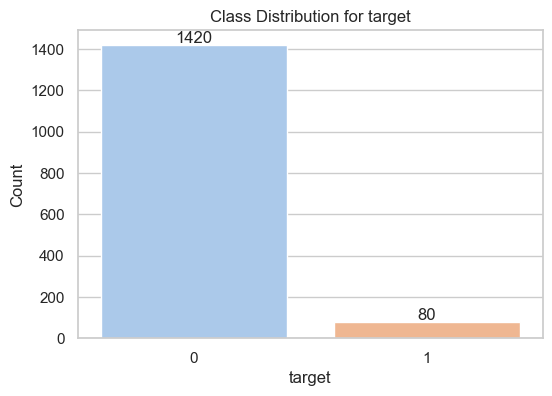

In [2]:
# Visualize the class distribution for the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='pastel')
plt.title('Class Distribution for target')
plt.xlabel('target')
plt.ylabel('Count')

counts = df['target'].value_counts().sort_index()
for index, value in enumerate(counts):
    plt.text(index, value + 10, str(value), ha='center')

plt.show()

## Implications of Class Imbalance on Predictive Model Performance

- **Biased predictions**: Many classifiers will favor the majority class, especially when trained with default settings. This can lead to models that predict the majority label most of the time and fail to detect the minority event.
- **Misleading accuracy**: A high overall accuracy is possible even if the model never correctly predicts the rare class. For example, if the minority class is only 5%, a model that always predicts the majority class still achieves 95% accuracy.
- **Poor recall for minority class**: Imbalanced data often leads to low recall for the rare class, which is problematic when the rare event is the one we most care about (fraud, disease, failure, etc.).
- **Evaluation metric selection**: Metrics such as precision, recall, F1-score, and AUC are more informative than accuracy for imbalanced classification. They help show how well the model identifies the minority class and balances false positives against false negatives.
- **Need for resampling or weighting**: Handling imbalance explicitly through resampling methods, algorithmic class weights, cost-sensitive learning, or threshold adjustment is usually necessary to build a reliable predictive model for this dataset.

# Part B: Baseline Model

This section trains baseline models on the original imbalanced dataset. No oversampling, undersampling, SMOTE, class weighting, or threshold adjustment is applied here, so these results can be used as the reference point for Part C.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Training class distribution:')
print(y_train.value_counts().sort_index())
print('\nTesting class distribution:')
print(y_test.value_counts().sort_index())

Training class distribution:
target
0    1136
1      64
Name: count, dtype: int64

Testing class distribution:
target
0    284
1     16
Name: count, dtype: int64


## Baseline Models

- **Logistic regression** is trained with feature scaling because it is sensitive to feature magnitude.
- **Decision tree** is trained directly on the numeric features because tree splits are scale-invariant.
- Both models use default class treatment, so the original 0/1 imbalance remains unchanged.

In [8]:
baseline_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
}


def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
    }


baseline_results = [
    evaluate_classifier(name, model, X_train, X_test, y_train, y_test)
    for name, model in baseline_models.items()
]

baseline_metrics = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['Confusion Matrix', 'Predictions']}
    for result in baseline_results
])

baseline_metrics.round(4)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.9500,1.0,0.0625,0.1176,0.7771
1,Decision Tree,0.9367,0.4,0.3750,0.3871,0.6717


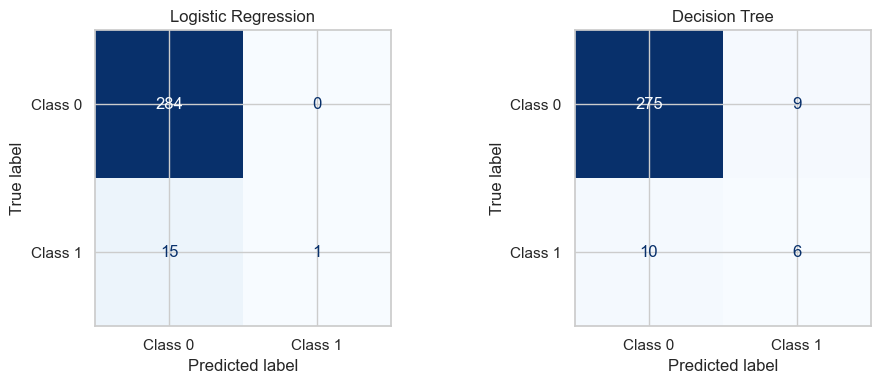

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, baseline_results):
    ConfusionMatrixDisplay(
        confusion_matrix=result['Confusion Matrix'],
        display_labels=['Class 0', 'Class 1'],
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(result['Model'])

plt.tight_layout()
plt.show()

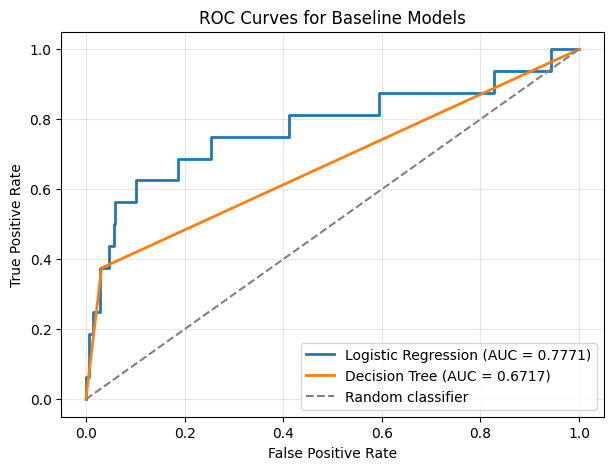

In [10]:
# Plot ROC curves for both baseline models and display AUC values
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))

for model_name, model in baseline_models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.title('ROC Curves for Baseline Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Baseline Results Discussion

The baseline results show why accuracy can be misleading for this imbalanced problem. The test set contains 284 majority-class observations and only 16 minority-class observations. Logistic regression achieves about 95% accuracy, but its recall for the minority class is only 0.0625, meaning it correctly detects only 1 out of 16 minority cases. Its high accuracy mainly comes from correctly predicting the majority class.

The decision tree has slightly lower accuracy at about 93.67%, but it identifies 6 out of 16 minority cases, giving a better recall and F1-score than logistic regression. This makes the decision tree the stronger baseline if detecting the minority event is more important than simply maximizing overall accuracy.

For Part C, the decision tree can be treated as the selected baseline model to improve with imbalance-handling methods, while logistic regression remains useful as a comparison point.